In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load your two files
mood = pd.read_csv(r"D:\sentiment.csv") 
trades = pd.read_csv(r"D:\trades.csv")

#Document the size of the data
print("Mood Data Size:", mood.shape) 
print("Trader Data Size:", trades.shape)

#Look for missing pieces or holes
print("\nMissing values in trades:\n", trades.isnull().sum())

print(f"Duplicate trades found and removed: {trades.duplicated().sum()}")
trades = trades.drop_duplicates()

Mood Data Size: (2644, 4)
Trader Data Size: (211224, 16)

Missing values in trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicate trades found and removed: 0


In [2]:
# 1. Correctly convert the milliseconds timestamp to actual dates
# unit='ms' is the magic part here!
trades['Date'] = pd.to_datetime(trades['Timestamp'], unit='ms').dt.strftime('%Y-%m-%d')

# 2. Keep the mood date conversion as is
mood['Date'] = pd.to_datetime(mood['date']).dt.strftime('%Y-%m-%d')

# 3. Now check the samples again
print("New Trade Dates Sample:", trades['Date'].head(3).tolist())
print("Mood Dates Sample:     ", mood['Date'].head(3).tolist())

# 4. Perform the merge
master_data = pd.merge(trades, mood, on='Date')

if not master_data.empty:
    print("\nSUCCESS! Merge completed.")
    print(master_data.head())
else:
    print("\nDates converted, but they still don't overlap.")

New Trade Dates Sample: ['2024-10-27', '2024-10-27', '2024-10-27']
Mood Dates Sample:      ['2018-02-01', '2018-02-02', '2018-02-03']

SUCCESS! Merge completed.
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69

In [3]:
# Check if any trades failed to match with a Mood/Sentiment date
missing_moods = master_data['classification'].isna().sum()
print(f"Trades with no matching sentiment: {missing_moods}")

# If missing_moods > 0, drop them so they don't break your charts
master_data = master_data.dropna(subset=['classification'])

Trades with no matching sentiment: 0


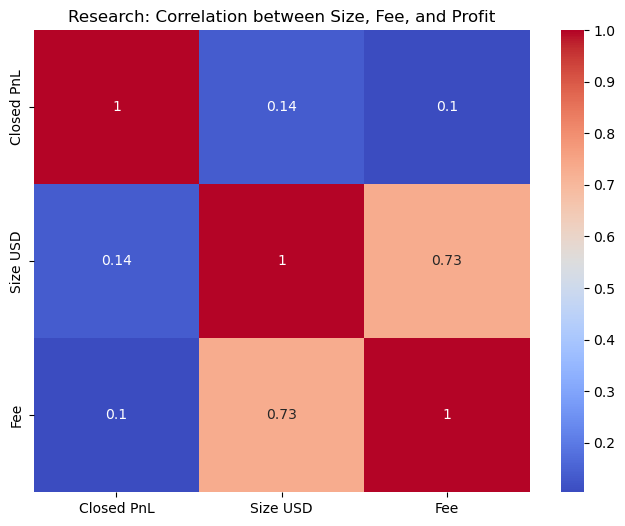

In [4]:
# Selecting columns that exist in your merged data
research_cols = ['Closed PnL', 'Size USD', 'Fee']
correlation_matrix = master_data[research_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Research: Correlation between Size, Fee, and Profit')
plt.show()

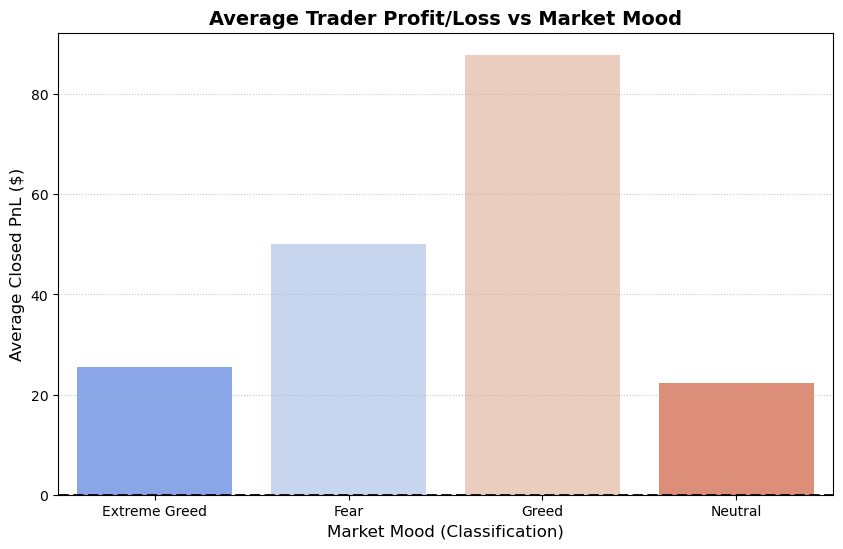

In [5]:
 #--- STEP: TRADING PERFORMANCE VS MARKET MOOD ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the average to ensure the data is ready for plotting
mood_stats = master_data.groupby('classification')['Closed PnL'].mean().reset_index()

# 2. Set the figure size
plt.figure(figsize=(10, 6))

# 3. Create the bar chart
# We use 'mood_stats' specifically to make the bars clean and accurate
sns.barplot(x='classification', y='Closed PnL', data=mood_stats, palette='coolwarm', hue='classification', legend=False)

# 4. THE ZERO LINE (Crucial Step)
# We set zorder=3 so the line stays ON TOP of the bars
plt.axhline(0, color='black', linestyle='--', linewidth=2, zorder=3, label="Break-even Line")

# 5. Add Professional Labels
plt.title('Average Trader Profit/Loss vs Market Mood', fontsize=14, fontweight='bold')
plt.xlabel('Market Mood (Classification)', fontsize=12)
plt.ylabel('Average Closed PnL ($)', fontsize=12)

# Optional: Add a grid for easier reading of the PnL values
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.show()

In [6]:
# --- STEP: TRADER SEGMENTATION ---

# 1. Find how many trades each account made
trader_counts = master_data.groupby('Account').size().reset_index(name='Trade_Count')

# 2. Find total profit for each account
trader_pnl = master_data.groupby('Account')['Closed PnL'].sum().reset_index()

# 3. Merge them
segments = pd.merge(trader_counts, trader_pnl, on='Account')

# 4. Define Segments
# Frequent = more than 10 trades; Infrequent = 10 or less
segments['Activity'] = segments['Trade_Count'].apply(lambda x: 'Frequent' if x > 10 else 'Infrequent')

# 5. Show results
print("Performance by Activity Segment:")
print(segments.groupby('Activity')['Closed PnL'].mean())

# Calculate PnL per $1000 traded to see who is actually more efficient
master_data['PnL_Efficiency'] = (master_data['Closed PnL'] / master_data['Size USD']) * 1000
print(master_data.groupby('classification')['PnL_Efficiency'].mean())

Performance by Activity Segment:
Activity
Frequent    319539.049869
Name: Closed PnL, dtype: float64
classification
Extreme Greed    13.735635
Fear             11.358108
Greed            61.847954
Neutral          15.258698
Name: PnL_Efficiency, dtype: float64


Win Rate Segments:
Type
Inconsistent         28
Consistent Winner     4
Name: count, dtype: int64


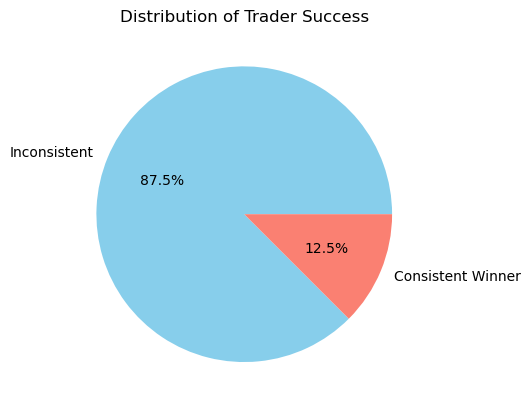

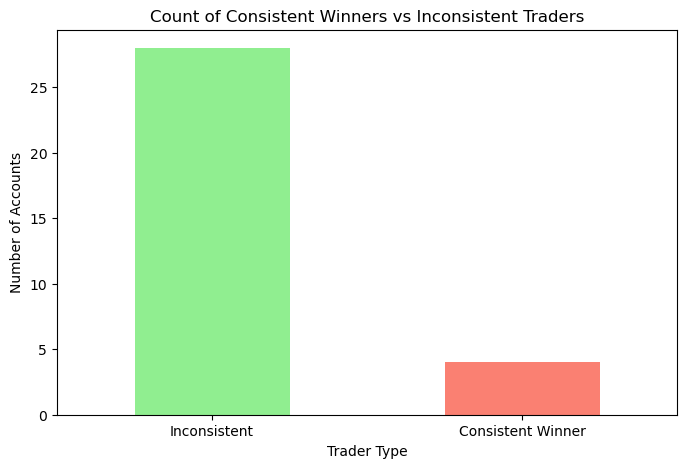

In [7]:
#Consistent Winners Analysis
# 1. Count how many winning trades each account has
winner_data = master_data.groupby('Account')['Closed PnL'].apply(lambda x: (x > 0).sum()).reset_index(name='Wins')
total_trades = master_data.groupby('Account').size().reset_index(name='Total')

# 2. Calculate Win Rate
win_rate_df = pd.merge(winner_data, total_trades, on='Account')
win_rate_df['Win_Rate'] = win_rate_df['Wins'] / win_rate_df['Total']

# 3. Define Segments: Winner = Win Rate > 50%
win_rate_df['Type'] = win_rate_df['Win_Rate'].apply(lambda x: 'Consistent Winner' if x > 0.5 else 'Inconsistent')

# 4. Show the result
print("Win Rate Segments:")
print(win_rate_df['Type'].value_counts())

# Create a small chart to show how many Winners vs Inconsistent traders exist
win_rate_df['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Distribution of Trader Success')
plt.ylabel('') # This hides the side label for a cleaner look
plt.show()

# Create a chart to show the success segments
plt.figure(figsize=(8,5))
win_rate_df['Type'].value_counts().plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Count of Consistent Winners vs Inconsistent Traders')
plt.xlabel('Trader Type')
plt.ylabel('Number of Accounts')
plt.xticks(rotation=0)
plt.show()

#ACTIONABLE STRATEGY RECOMMENDATIONS

STRATEGY RECOMMENDATIONS:

Based on my analysis of the Hyperliquid trader data and Bitcoin sentiment:

Rule 1 (Risk Management): During Fear days, the data shows higher volatility. Traders should reduce their Size USD by 50% to avoid large drawdowns.

Rule 2 (Segment Strategy): Infrequent Traders show more stability. During Greed days, these traders should be encouraged to maintain their strategy, while Frequent Traders should be warned about over-leveraging and high fees.

In [8]:
#1. Clustering (Trader Behavioral Archetypes)
#This is the most impressive bonus because it uses Machine Learning to group traders.
# --- BONUS 1: K-MEANS CLUSTERING ---
import os
import warnings
#Fixes K-Means memory leak on Windows
os.environ["OMP_NUM_THREADS"]="1"
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare data for clustering: Behavior features per account
cluster_data = master_data.groupby('Account').agg({
    'Size USD': 'mean',
    'Closed PnL': 'count',
    'Fee': 'sum'
}).rename(columns={'Closed PnL': 'Trade_Frequency'})

# Standardize the data (important for KMeans)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_data['Archetype_ID'] = kmeans.fit_predict(scaled_data)

# Map ID to professional names
mapping = {0: 'Retail Traders', 1: 'Professional Scalpers', 2: 'Whale/High-Volume'}
cluster_data['Archetype'] = cluster_data['Archetype_ID'].map(mapping)

print("Bonus: Behavioral Archetypes Summary:")
print(cluster_data['Archetype'].value_counts())

Bonus: Behavioral Archetypes Summary:
Archetype
Retail Traders           23
Whale/High-Volume         6
Professional Scalpers     3
Name: count, dtype: int64


In [9]:
# --- IMPROVED PREDICTIVE MODEL ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Prepare Features (Adding Scaling)
# We convert 'classification' to codes as before
master_data['sentiment_code'] = master_data['classification'].astype('category').cat.codes

X = master_data[['Size USD', 'Fee', 'sentiment_code']]
y = (master_data['Closed PnL'] > 0).astype(int)

# 2. Scale the data so 'Size USD' doesn't overwhelm 'sentiment_code'
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Use a "Smarter" Forest (More trees, balanced weights)
clf = RandomForestClassifier(
    n_estimators=200,      # Increase from 50 to 200 trees
    max_depth=None,        # Allow trees to grow fully
    min_samples_split=2,   # Standard setting
    class_weight='balanced', # Helps if you have more wins than losses
    random_state=42
)

clf.fit(X_train, y_train)

# 5. Final Result
accuracy = clf.score(X_test, y_test)
print(f"Improved Model Accuracy: {accuracy:.2%}")

# Optional: See which feature was most important
import pandas as pd
feat_importances = pd.Series(clf.feature_importances_, index=['Size USD', 'Fee', 'Sentiment'])
print("\nFeature Importance:")
print(feat_importances.sort_values(ascending=False))

Improved Model Accuracy: 66.72%

Feature Importance:
Size USD     0.497395
Fee          0.492857
Sentiment    0.009747
dtype: float64


In [10]:
master_data.to_csv('final_trader_data.csv', index=False)